In [8]:
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    VecFrameStack,
    VecEnvWrapper
)
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import json
import time
from collections import defaultdict

gym.register_envs(ale_py)

Reward Shaping Wrapper

In [ ]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARD = {200, 400, 800, 1600}
    FRUIT_REWARD = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150

    def __init__(self, env,
                 ghost_chain_bonus=50.0,
                 ghost_hunt_bonus=20.0,
                 missed_ghost_penalty=-15.0,
                 timing_bonus=30.0,
                 pellet_streak_bonus=0.5,
                 fruit_multiplier=2.0, 
                 death_penalty=-25.0,):
        super().__init__(env)
        self.ghost_chain_bonus     = ghost_chain_bonus
        self.ghost_hunt_bonus      = ghost_hunt_bonus
        self.missed_ghost_penalty  = missed_ghost_penalty
        self.timing_bonus    = timing_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty    = death_penalty
       
        # State tracking for reward shaping
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward 
 
        # Initialise lives tracker 
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power pellet tracking
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                if self.ghosts_eaten == 0:
                    shaped_reward += self.missed_ghost_penalty * 2
                elif self.ghosts_eaten == 1:
                    shaped_reward += self.missed_ghost_penalty
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0

        # Ghost eaten

        # Pellet streak

        # Fruit multiplier

        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
 
        return obs, shaped_reward, terminated, truncated, info

Define the 4 Experimental Conditions

In [10]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "#4C9BE8",
        "description": "Default ALE rewards only"
    },

    "Death Penalty": {
        "wrapper": "simple",
        "survival_bonus": 0.0, 
        "death_penalty": -25.0,
        "power_pellet_bonus": 0.0,
        "color": "#57C97A",
        "description": "-25 on each life lost"
    },

    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 50.0,
        "timing_bonus": 30.0,
        "pelet_streak_bonus": 0.5,
        "fruit_multiplier": 2.0, 
        "death_penalty": -25.0,    
        "color": "#C97AE8",
        "description": "Ghost chain + pellet streak +fruit + death penalty"
    },

    "Expert No Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 50.0,
        "timing_bonus": 30.0,
        "pelet_streak_bonus": 0.5,
        "fruit_multiplier": 2.0, 
        "death_penalty": 0.0,    
        "color": "#E8C94C",
        "description": "Ghost chain + pellet streak +fruit, no death penalty"
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:20s} — {cfg['description']}")

Conditions defined:
  Baseline             — Default ALE rewards only
  Death Penalty        — -25 on each life lost
  Expert Shaping       — Ghost chain + pellet streak +fruit + death penalty
  Expert No Death Penalty — Ghost chain + pellet streak +fruit, no death penalty


Progress Callback (tracks metrics per episode)

In [21]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose=0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0
        self._current_length = 0
 
    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1
 
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0
            self._current_length = 0
            if len(self.episode_rewards) % 50 == 0:
                recent_r = np.mean(self.episode_rewards[-20:])
                recent_l = np.mean(self.episode_lengths[-20:])
                print(f"  [{self.condition_name}] "
                      f"Ep {len(self.episode_rewards):>4} | "
                      f"Steps {self.num_timesteps:>7,} | "
                      f"Avg reward: {recent_r:>7.1f} | "
                      f"Avg length: {recent_l:>5.0f}")
        return True
 

Training Function

In [26]:
def make_env(condition_name, condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5")
        env = RewardShapingWrapper(
            env,
            ghost_chain_bonus=condition_cfg.get("ghost_chain_bonus", 0.0),
            ghost_hunt_bonus=condition_cfg.get("ghost_hunt_bonus", 0.0),
            missed_ghost_penalty=condition_cfg.get("missed_ghost_penalty", 0.0),
            timing_bonus=condition_cfg.get("timing_bonus", 0.0),
            pellet_streak_bonus=condition_cfg.get("pellet_streak_bonus", 0.0),
            fruit_multiplier=condition_cfg.get("fruit_multiplier", 1.0),
            death_penalty=condition_cfg.get("death_penalty", 0.0),
        )
        return env
    return _init
 
 
def train_condition(condition_name, condition_cfg,
                    total_timesteps=100_000, seed=42):
    print(f"\n{'='*60}")
    print(f"Training: {condition_name}")
    print(f"Config:   {condition_cfg['description']}")
    print(f"{'='*60}")

    def make_env_fn():
        env = gym.make("ALE/MsPacman-v5")
        env = RewardShapingWrapper(
            env,
            ghost_chain_bonus=condition_cfg.get("ghost_chain_bonus", 0.0),
            ghost_hunt_bonus=condition_cfg.get("ghost_hunt_bonus", 0.0),
            missed_ghost_penalty=condition_cfg.get("missed_ghost_penalty", 0.0),
            timing_bonus=condition_cfg.get("timing_bonus", 0.0),
            pellet_streak_bonus=condition_cfg.get("pellet_streak_bonus", 0.0),
            fruit_multiplier=condition_cfg.get("fruit_multiplier", 1.0),
            death_penalty=condition_cfg.get("death_penalty", 0.0),
        )
        env = AtariWrapper(env, clip_reward=False)
        return env

    vec_env = DummyVecEnv([make_env_fn])
    vec_env = VecFrameStack(vec_env, n_stack=4)

    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps=128,
        batch_size=256,
        n_epochs=4,
        gamma=0.99,
        learning_rate=2.5e-4,
        clip_range=0.1,
        verbose=0,
        seed=seed,
    )

    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)


    vec_env.close()
    return model, callback

Run All 4 Training Conditions

In [6]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


In [27]:
TOTAL_STEPS = 100_000
 
results = {} 
 
for name, cfg in CONDITIONS.items():
    model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
    results[name] = {
        "callback": callback,
        "model": model,
        "episode_rewards": callback.episode_rewards,
        "episode_lengths": callback.episode_lengths,
    }
 
print("\nAll conditions trained!")


Training: Baseline
Config:   Default ALE rewards only


g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


KeyboardInterrupt: 

Evaluation Function (epsilon=0, real game rewards)

In [ ]:
def evaluate_agent(model, condition_cfg, n_episodes=100, seed=99):
    def make_env_fn():
        env = gym.make("ALE/MsPacman-v5")
        env = RewardShapingWrapper(
            env,
            ghost_chain_bonus=condition_cfg.get("ghost_chain_bonus", 0.0),
            ghost_hunt_bonus=condition_cfg.get("ghost_hunt_bonus", 0.0),
            missed_ghost_penalty=condition_cfg.get("missed_ghost_penalty", 0.0),
            timing_bonus=condition_cfg.get("timing_bonus", 0.0),
            pellet_streak_bonus=condition_cfg.get("pellet_streak_bonus", 0.0),
            fruit_multiplier=condition_cfg.get("fruit_multiplier", 1.0),
            death_penalty=condition_cfg["death_penalty"],
        )
        env = AtariWrapper(env, clip_reward=False)
        return env

    eval_env = DummyVecEnv([make_env_fn])
    eval_env = VecFrameStack(eval_env, n_stack=4)

    scores, lengths = [], []
    for ep in range(n_episodes):
        obs = eval_env.reset()
        total_reward, length, done = 0, 0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = eval_env.step(action)
            total_reward += reward[0]
            length += 1                           
        scores.append(total_reward)
        lengths.append(length)                     
    eval_env.close()
    return np.array(scores), np.array(lengths)

Evaluate All Conditions

In [12]:
eval_results = {}
 
for name, data in results.items():
    print(f"Evaluating {name}...")
    scores, lengths = evaluate_agent(data["model"], CONDITIONS[name], n_episodes=100)
    eval_results[name] = {"scores": scores, "lengths": lengths}
    print(f"  Avg score:  {scores.mean():.1f} ± {scores.std():.1f}")
    print(f"  Avg length: {lengths.mean():.1f}")

Evaluating Baseline...
  Avg score:  23.8 ± 33.2
  Avg length: 41.6
Evaluating Survival Bonus...
  Avg score:  21.8 ± 28.6
  Avg length: 36.3
Evaluating Death Penalty...
  Avg score:  -29.6 ± 28.4
  Avg length: 36.3
Evaluating Dense Shaping...
  Avg score:  16.3 ± 90.6
  Avg length: 41.8


Learning Curves (all 4 on one graph)

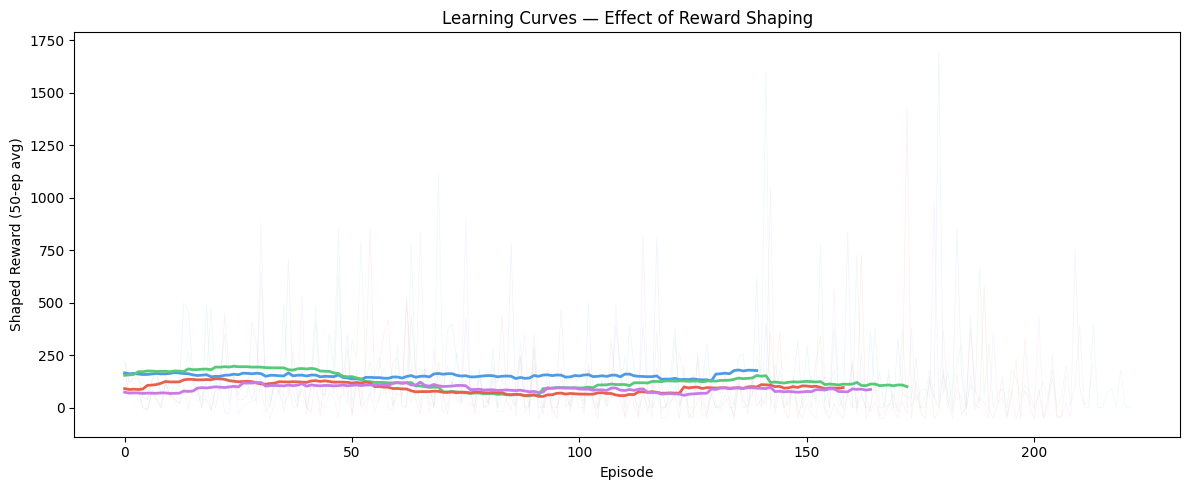

In [21]:
def smooth(arr, window=50):
    if len(arr) < window:
        return np.array(arr)
    return np.convolve(arr, np.ones(window)/window, mode='valid')
 
fig, ax = plt.subplots(figsize=(12, 5))
 
for name, data in results.items():
    cfg = CONDITIONS[name]
    rewards = data["episode_rewards"]
    smoothed = smooth(rewards, window=50)
    episodes = np.arange(len(smoothed))
 
    ax.plot(episodes, smoothed,
            color=cfg["color"], linewidth=2, label=name)
    # faint raw line
    ax.plot(np.arange(len(rewards)), rewards,
            color=cfg["color"], alpha=0.1, linewidth=0.5)
 
ax.set_xlabel("Episode")
ax.set_ylabel("Shaped Reward (50-ep avg)")
ax.set_title("Learning Curves — Effect of Reward Shaping")
plt.tight_layout()
plt.savefig("plot_learning_curves.png")
plt.show()

Score Distribution (box plot)

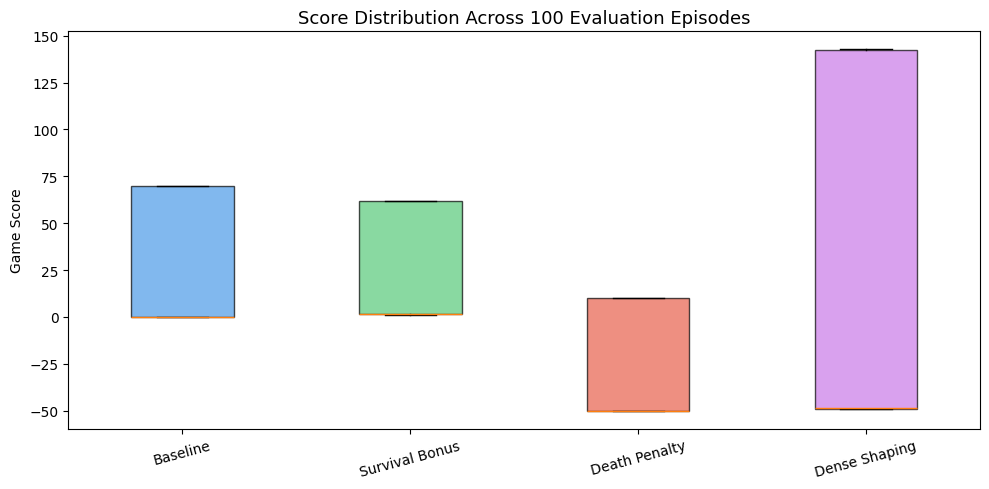

Saved plot_score_distribution.png


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
 
data_to_plot = [eval_results[n]["scores"] for n in names]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False)
 
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
 
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Game Score")
ax.set_title("Score Distribution Across 100 Evaluation Episodes", fontsize=13)
plt.tight_layout()
plt.savefig("plot_score_distribution.png", dpi=130)
plt.show()
print("Saved plot_score_distribution.png")

Summary Table

In [23]:
print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(f"{'Condition':<20} {'Avg Score':>10} {'Std':>8} "
      f"{'Avg Length':>12} {'Max Score':>10}")
print("-"*70)
 
for name in names:
    s = eval_results[name]["scores"]
    l = eval_results[name]["lengths"]
    print(f"{name:<20} {s.mean():>10.1f} {s.std():>8.1f} "
          f"{l.mean():>12.1f} {s.max():>10.0f}")
 
print("="*70)


EXPERIMENT SUMMARY
Condition             Avg Score      Std   Avg Length  Max Score
----------------------------------------------------------------------
Baseline                   23.8     33.2         41.6         70
Survival Bonus             21.8     28.6         36.3         62
Death Penalty             -29.6     28.4         36.3         10
Dense Shaping              16.3     90.6         41.8        143
